任务目标说明：
1. 比对两种 Hash 的查全率与执行效率，两种 Hash 为：
    * 文章 -> 分词 -> 5-gram Shingle -> MinHash -> Top N
    * 文章 -> 分词 -> 5-gram Shingle -> SimHash -> Top N
2. Top N 取值范围：{10, 20, 30, 40, ..., 100}
3. 代码采用 Python 编写。

最终确认评估口径：
1. 数据来源：使用 cell1 中的 DB Connection 连接 MySQL，并用 sql_1 获取评估数据；保持 sql_1 当前 limit 20000 的样本范围。
2. 目标文档：sql_1 查询结果中的 content_raw。
3. 候选库：同一个 workId_raw 下的 content_cand 集合；每个 workId_raw 单独使用自己的候选库计算 Top N。
4. 正样本定义：repeat_rate >= 0.45 的 raw-cand 对为目标结果。
5. 查全率口径：采用方案 B，按所有正样本对逐条统计命中率。
   - 对每个 workId_raw，在其候选库中计算 content_raw 与所有 content_cand 的 hash 相似度。
   - 对每个 Top N，取相似度最高的 N 个 workId_cand。
   - recall@N = 命中的正样本对数量 / 全部正样本对数量。
6. Shingle 口径：使用 jieba 分词后做 5-gram；允许安装 jieba。
7. MinHash 参数：num_perm = 128，代码中保留配置项便于调整。
8. SimHash 参数：hash_bits = 128，代码中保留配置项便于调整。
9. 耗时统计：分开统计 build time 与 query time。
   - build time：分词、shingle、签名/向量生成等预处理耗时。
   - query time：对每个 content_raw 计算候选相似度、排序并取 Top N 的耗时。
10. is_same_user：仅表示数据来源，本次测试不作为过滤或分组条件。
11. 空数据处理：content_raw 或 content_cand 为空时，从测试样本中剔除，并记录剔除数量。
12. 重复样本处理：按 workId_raw + workId_cand 去重，保留 repeat_rate 最大的记录。
13. 候选数量小于 Top N 时，实际取 min(N, 候选数量)。
14. 输出结果：生成表格，对比 MinHash 与 SimHash 在不同 Top N 下的 recall、build time、query time。

In [32]:
# cell1 
## DB Connection 
server_address ='rm-uf6ze085xr2kl4smzno.mysql.rds.aliyuncs.com'
port=3306
username='reader'
password='JBEj1D4f'
database='ai'

## SQL Query
sql_1 ="""
with repetition_cut as (
select * from ai.repetition_rate_record_log order by id desc limit 40000
),

historic_essay as (
select 
c.id as workId_raw,
c.user_id as userId_raw,
c.composition_title as title_raw,
c.composition_content as content_raw,
b.id as workId_cand,
b.user_id as userId_cand,
b.composition_title as title_cand,
b.composition_content as content_cand,
a.repeat_rate as repeat_rate,
case when c.user_id = b.user_id then 1 else 0 end as is_same_user
from 
    repetition_cut a
    inner join ai.correct_task b 
    on a.candidate_id = b.id 
    inner join ai.correct_task c 
    on a.work_id =c.id 
)

select distinct * from historic_essay 
"""

In [42]:
# cell2: 参数配置、依赖安装与通用工具
import sys
import subprocess
import time
import re
import hashlib
import heapq
from collections import defaultdict

import numpy as np
import pandas as pd
from sqlalchemy import create_engine

try:
    import jieba
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "jieba"])
    import jieba

try:
    display
except NameError:
    from IPython.display import display

TOP_N_LIST = list(range(10, 101, 10))
POSITIVE_REPEAT_RATE_THRESHOLD = 0.45
SHINGLE_N = 5
MINHASH_NUM_PERM = 32
SIMHASH_BITS = 256
MINHASH_RANDOM_SEED = 42
CACHE_SIMILARITIES_FOR_QUERY = False

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{server_address}:{port}/{database}?charset=utf8mb4"
)

def run_sql(sql: str) -> tuple[pd.DataFrame, float]:
    t0 = time.perf_counter()
    df = pd.read_sql(sql, engine)
    cost_ms = (time.perf_counter() - t0) * 1000
    return df, cost_ms

def normalize_text(text) -> str:
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", "", str(text)).strip()

def tokenize(text: str) -> list[str]:
    return [tok.strip() for tok in jieba.lcut(text) if tok.strip()]

def make_shingles_from_tokens(tokens: list[str], n: int = SHINGLE_N) -> set[str]:
    if len(tokens) < n:
        return set()
    return {"␟".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)}

def text_to_shingles(text: str) -> set[str]:
    return make_shingles_from_tokens(tokenize(text), SHINGLE_N)

def stable_hash_int(text: str, digest_size: int = 8) -> int:
    digest = hashlib.blake2b(text.encode("utf-8"), digest_size=digest_size).digest()
    return int.from_bytes(digest, byteorder="big", signed=False)


In [43]:
# cell3: 查询数据、清洗空文本、按 workId_raw + workId_cand 去重
# version: 2026-06-16 add LIMIT/query_ms diagnostic stats
df_raw, sql_cost_ms = run_sql(sql_1)
print(f"sql_1 查询耗时: {sql_cost_ms:.2f} ms, 原始行数: {len(df_raw):,}")

required_cols = ["workId_raw", "content_raw", "workId_cand", "content_cand", "repeat_rate"]
missing_cols = [col for col in required_cols if col not in df_raw.columns]
if missing_cols:
    raise ValueError(f"sql_1 缺少必要字段: {missing_cols}")

df_eval = df_raw.copy()
df_eval["content_raw"] = df_eval["content_raw"].map(normalize_text)
df_eval["content_cand"] = df_eval["content_cand"].map(normalize_text)
df_eval["repeat_rate"] = pd.to_numeric(df_eval["repeat_rate"], errors="coerce")

before_clean = len(df_eval)
df_eval = df_eval[
    df_eval["content_raw"].ne("")
    & df_eval["content_cand"].ne("")
    & df_eval["repeat_rate"].notna()
].copy()
empty_removed = before_clean - len(df_eval)

before_dedup = len(df_eval)
df_eval = (
    df_eval
    .sort_values("repeat_rate", ascending=False)
    .drop_duplicates(["workId_raw", "workId_cand"], keep="first")
    .copy()
)
duplicate_removed = before_dedup - len(df_eval)

positive_pair_count = int((df_eval["repeat_rate"] >= POSITIVE_REPEAT_RATE_THRESHOLD).sum())
work_count = df_eval["workId_raw"].nunique()
candidate_pair_count = len(df_eval)

print(f"清洗空文本/无效 repeat_rate 剔除行数: {empty_removed:,}")
print(f"workId_raw + workId_cand 去重剔除行数: {duplicate_removed:,}")
print(f"评估 workId_raw 数: {work_count:,}")
print(f"评估候选 pair 数: {candidate_pair_count:,}")
print(f"正样本 pair 数 repeat_rate >= {POSITIVE_REPEAT_RATE_THRESHOLD}: {positive_pair_count:,}")

# 诊断 LIMIT 增大后 query_ms 增量来源：raw 数、有效 pair 数、每个 raw 下候选数分布
candidate_stats = (
    df_eval.groupby("workId_raw", as_index=False)
    .agg(candidate_cnt=("workId_cand", "nunique"))
)

candidate_summary = candidate_stats["candidate_cnt"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).to_frame("candidate_cnt")

candidate_bucket_bins = [0, 10, 20, 50, 100, 200, 500, 1000, float("inf")]
candidate_bucket_labels = ["1-10", "11-20", "21-50", "51-100", "101-200", "201-500", "501-1000", "1000+"]
candidate_stats["candidate_cnt_bucket"] = pd.cut(
    candidate_stats["candidate_cnt"],
    bins=candidate_bucket_bins,
    labels=candidate_bucket_labels,
    include_lowest=True,
    right=True,
)
candidate_bucket_summary = (
    candidate_stats.groupby("candidate_cnt_bucket", observed=True)
    .agg(workId_raw_count=("workId_raw", "count"))
    .reset_index()
)

print("\nLIMIT 增大后 query_ms 增量来源诊断：")
print(f"workId_raw 数量: {candidate_stats.shape[0]:,}")
print(f"去重后 raw-cand pair 数: {candidate_pair_count:,}")
print(f"平均每个 raw 的候选数: {candidate_stats['candidate_cnt'].mean():.2f}")
print(f"最大候选数: {candidate_stats['candidate_cnt'].max():,}")
print(f"候选数 P95: {candidate_stats['candidate_cnt'].quantile(0.95):.2f}")
print(f"候选数 P99: {candidate_stats['candidate_cnt'].quantile(0.99):.2f}")

print("候选数分布 describe：")
display(candidate_summary)
print("候选数分桶：")
display(candidate_bucket_summary)

display(df_eval.head(10))


sql_1 查询耗时: 13588.29 ms, 原始行数: 39,476
清洗空文本/无效 repeat_rate 剔除行数: 0
workId_raw + workId_cand 去重剔除行数: 0
评估 workId_raw 数: 41
评估候选 pair 数: 39,476
正样本 pair 数 repeat_rate >= 0.45: 5

LIMIT 增大后 query_ms 增量来源诊断：
workId_raw 数量: 41
去重后 raw-cand pair 数: 39,476
平均每个 raw 的候选数: 962.83
最大候选数: 1,175
候选数 P95: 1172.00
候选数 P99: 1175.00
候选数分布 describe：


,candidate_cnt
count,41.000000
mean,962.829268
std,299.976158
min,120.000000
50%,1081.000000
75%,1091.000000
90%,1146.000000
95%,1172.000000
99%,1175.000000
max,1175.000000


候选数分桶：


,candidate_cnt_bucket,workId_raw_count
0,101-200,2
1,201-500,4
2,501-1000,2
3,1000+,33


,workId_raw,userId_raw,title_raw,content_raw,workId_cand,userId_cand,title_cand,content_cand,repeat_rate,is_same_user
16899,4815,100000000014609,未写作文,内容为空白。内容为空白。内容为空白。,3085,100000000002275,未写作文,内容为空白。内容为空白。内容为空白。,1.0000,0
30095,4799,238255404625920,AI时代，成长需要独立思考,人工智能飞速发展的今天，便捷渗透在学习的方方面面。整理素材、构思行文、完整成文，AI轻点几下...,4085,238255404625920,AI时代，成长需要独立思考,人工智能飞速发展的今天，便捷渗透在学习的方方面面。整理素材、构思行文、完整成文，AI轻点几下...,0.7097,1
32940,4796,471810726572032,青春，热辣滚烫,冬日的活动室里，寒气像无形的丝线，丝丝缕缕地钻进骨髓，桌面上的硬卡纸如被狂风席卷过一般，凌乱...,4681,471810726572032,青春，热辣滚烫,冬日的活动室透着寒意，桌面上堆着凌乱的硬卡纸。距离市中学生艺术展仅剩一周，我的心却如这气温般...,0.6866,1
32855,4802,424946228662272,回首那一丝苦涩,当我手持“越王勾践剑”，在展厅的灯光下挥出锐利的剑光，回首望去，才真正读懂：一时的苦恼从来不...,4454,424946228662272,回首那一丝苦涩,当我手持“越王勾践剑”，在展厅的灯光下挥出锐利的剑花，回首望去，才真正读懂：一时的苦恼从来不...,0.6667,1
1493,4830,253505386459136,慢一点，又何妨,"迈入初三,大家都在快节奏中奔跑,可我却在想,慢一点,又何妨?时光仿佛被按下快进键,试卷像雪花...",4268,253505386459136,慢一点，又何妨,迈入初三，时光仿佛被按下快进键。试卷堆叠如山，刷题、考试、改错成为生活的主旋律。看着一次次测...,0.6316,1
35086,4795,457990494892032,烟火里的传承,在端午的烟火气息中，藏着老祖宗传下来的手艺，可人们却在快节奏的生活中渐渐遗忘了这份传承。初夏...,3531,457990494892032,烟火里的传承,在烟火气十足的城市生活中，人们往往都喜欢快捷便利的方式，而忽略了那些传统手艺的传承。初夏风暖...,0.4255,1
23763,4806,303525938728960,比看上去更有意思,"暑假,和家人漫步在杭州的古巷,阳光慵懒地洒在青石板上。突然,妹妹像只欢快的小鹿,指着巷口那家...",4708,303525938728960,比看上去更有意思,和家人去杭州旅游，有一天在一个巷口发现有一家漆扇制作体验馆，妹妹执意要去玩，我对此嗤之以鼻，...,0.3590,1
16423,4812,303525938728960,比看上去更有意思,"暑假,和家人漫步在杭州的古巷,阳光慵懒地洒在青石板上。突然,妹妹像只欢快的小鹿,指着巷口那家...",4708,303525938728960,比看上去更有意思,和家人去杭州旅游，有一天在一个巷口发现有一家漆扇制作体验馆，妹妹执意要去玩，我对此嗤之以鼻，...,0.3590,1
9526,4819,487257270259712,美好瞬间,“海上生明月，天涯共此时。”又是一年中秋夜，我坐在老宅桂花树下，洁白的月光如纱般轻柔地洒进庭...,4394,487257270259712,美好瞬间,“海上生明月，天涯共此时。”又是一年中秋夜，我坐在老宅桂花树下，洁白的月光洒进庭院，像撒了一...,0.2857,1
602,4831,236430924328960,慢一点又何妨,"体育模拟中考的跳绳赛场,大风卷着尘土掠过塑胶跑道,当老师高声报出418个的成绩时,我攥着磨得...",128,459006665695232,原来他也有光芒,他总是安静的待在我们身边，像一片落叶。大扫除时攥着半干的抹布，阳光里的浮沉跳着舞，却照不亮她...,0.0580,0


In [44]:
# cell4: MinHash 与 SimHash 实现
MINHASH_PRIME = 2_147_483_647
_rng = np.random.default_rng(MINHASH_RANDOM_SEED)
_MINHASH_A = _rng.integers(1, MINHASH_PRIME - 1, size=MINHASH_NUM_PERM, dtype=np.int64)
_MINHASH_B = _rng.integers(0, MINHASH_PRIME - 1, size=MINHASH_NUM_PERM, dtype=np.int64)

def minhash_signature(shingles: set[str]) -> np.ndarray:
    if not shingles:
        return np.full(MINHASH_NUM_PERM, MINHASH_PRIME, dtype=np.int64)
    values = np.array(
        [stable_hash_int(shingle, digest_size=8) % MINHASH_PRIME for shingle in shingles],
        dtype=np.int64,
    )
    signature = np.full(MINHASH_NUM_PERM, MINHASH_PRIME, dtype=np.int64)
    chunk_size = 512
    for start in range(0, len(values), chunk_size):
        chunk = values[start:start + chunk_size]
        hashed = (_MINHASH_A[:, None] * chunk[None, :] + _MINHASH_B[:, None]) % MINHASH_PRIME
        signature = np.minimum(signature, hashed.min(axis=1))
    return signature

def minhash_similarity(sig_a: np.ndarray, sig_b: np.ndarray) -> float:
    return float(np.mean(sig_a == sig_b))

def simhash_signature(shingles: set[str]) -> int:
    if not shingles:
        return 0
    weights = np.zeros(SIMHASH_BITS, dtype=np.int32)
    digest_size = SIMHASH_BITS // 8
    for shingle in shingles:
        digest = hashlib.blake2b(shingle.encode("utf-8"), digest_size=digest_size).digest()
        bits = np.unpackbits(np.frombuffer(digest, dtype=np.uint8))
        weights += np.where(bits > 0, 1, -1)
    signature = 0
    for bit in weights >= 0:
        signature = (signature << 1) | int(bit)
    return signature

def simhash_similarity(sig_a: int, sig_b: int) -> float:
    distance = (sig_a ^ sig_b).bit_count()
    return 1.0 - distance / SIMHASH_BITS

def build_signatures(df: pd.DataFrame, method: str):
    doc_texts = {}
    for row in df.itertuples(index=False):
        doc_texts[("raw", row.workId_raw)] = row.content_raw
        doc_texts[("cand", row.workId_cand)] = row.content_cand

    signature_fn = minhash_signature if method == "MinHash" else simhash_signature

    t0 = time.perf_counter()
    signatures = {}
    empty_shingle_docs = 0
    for doc_key, text in doc_texts.items():
        shingles = text_to_shingles(text)
        if not shingles:
            empty_shingle_docs += 1
        signatures[doc_key] = signature_fn(shingles)
    build_ms = (time.perf_counter() - t0) * 1000
    return signatures, build_ms, len(doc_texts), empty_shingle_docs


In [45]:
# cell5: 执行评估，输出 TopN 维度查全率与耗时表格
def evaluate_method(df: pd.DataFrame, method: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    if method == "MinHash":
        similarity_fn = minhash_similarity
    elif method == "SimHash":
        similarity_fn = simhash_similarity
    else:
        raise ValueError(f"unknown method: {method}")

    signatures, build_ms, doc_count, empty_shingle_docs = build_signatures(df, method)
    total_positive_pairs = int((df["repeat_rate"] >= POSITIVE_REPEAT_RATE_THRESHOLD).sum())

    groups = []
    for work_id, group in df.groupby("workId_raw"):
        raw_sig = signatures[("raw", work_id)]
        cand_ids = group["workId_cand"].tolist()
        positive_ids = set(group.loc[group["repeat_rate"] >= POSITIVE_REPEAT_RATE_THRESHOLD, "workId_cand"].tolist())
        groups.append((work_id, raw_sig, cand_ids, positive_ids))

    rows = []
    detail_rows = []

    cached_sims = None
    if CACHE_SIMILARITIES_FOR_QUERY:
        cached_sims = {}
        t0_cache = time.perf_counter()
        for work_id, raw_sig, cand_ids, _positive_ids in groups:
            cached_sims[work_id] = [
                (similarity_fn(raw_sig, signatures[("cand", cand_id)]), cand_id)
                for cand_id in cand_ids
            ]
        cache_query_ms = (time.perf_counter() - t0_cache) * 1000
    else:
        cache_query_ms = 0.0

    for top_n in TOP_N_LIST:
        t0 = time.perf_counter()
        hit_positive_pairs = 0
        evaluated_work_count = 0

        for work_id, raw_sig, cand_ids, positive_ids in groups:
            if not cand_ids:
                continue
            evaluated_work_count += 1
            actual_n = min(top_n, len(cand_ids))

            if CACHE_SIMILARITIES_FOR_QUERY:
                sims = cached_sims[work_id]
            else:
                sims = [
                    (similarity_fn(raw_sig, signatures[("cand", cand_id)]), cand_id)
                    for cand_id in cand_ids
                ]

            top_ids = {cand_id for _score, cand_id in heapq.nlargest(actual_n, sims, key=lambda x: x[0])}
            hit_positive_pairs += len(positive_ids & top_ids)

            detail_rows.append({
                "method": method,
                "top_n": top_n,
                "workId_raw": work_id,
                "candidate_count": len(cand_ids),
                "actual_top_n": actual_n,
                "positive_count": len(positive_ids),
                "hit_positive_count": len(positive_ids & top_ids),
            })

        query_ms = (time.perf_counter() - t0) * 1000 + cache_query_ms
        recall = hit_positive_pairs / total_positive_pairs if total_positive_pairs else np.nan
        rows.append({
            "method": method,
            "top_n": top_n,
            "recall": recall,
            "hit_positive_pairs": hit_positive_pairs,
            "total_positive_pairs": total_positive_pairs,
            "build_ms": build_ms,
            "query_ms": query_ms,
            "avg_query_ms_per_work": query_ms / evaluated_work_count if evaluated_work_count else np.nan,
            "evaluated_work_count": evaluated_work_count,
            "candidate_pair_count": len(df),
            "signature_doc_count": doc_count,
            "empty_shingle_doc_count": empty_shingle_docs,
        })

    return pd.DataFrame(rows), pd.DataFrame(detail_rows)

all_results = []
all_details = []
for method_name in ["MinHash", "SimHash"]:
    print(f"开始评估 {method_name} ...")
    result_df, detail_df = evaluate_method(df_eval, method_name)
    all_results.append(result_df)
    all_details.append(detail_df)
    print(f"{method_name} 完成")

result_table = pd.concat(all_results, ignore_index=True)
detail_table = pd.concat(all_details, ignore_index=True)

result_table["recall_pct"] = result_table["recall"] * 100
result_table = result_table[[
    "method", "top_n", "recall", "recall_pct", "hit_positive_pairs", "total_positive_pairs",
    "build_ms", "query_ms", "avg_query_ms_per_work", "evaluated_work_count",
    "candidate_pair_count", "signature_doc_count", "empty_shingle_doc_count",
]]

print("评估结果：")
display(result_table)

print("Recall 对比：")
display(result_table.pivot(index="top_n", columns="method", values="recall"))
print("Avg query time per work(ms) 对比：")
display(result_table.pivot(index="top_n", columns="method", values="avg_query_ms_per_work"))

result_table.to_csv("hash_recall_efficiency_summary.csv", index=False, encoding="utf-8-sig")
detail_table.to_csv("hash_recall_efficiency_detail.csv", index=False, encoding="utf-8-sig")
print("已导出：hash_recall_efficiency_summary.csv / hash_recall_efficiency_detail.csv")


开始评估 MinHash ...
MinHash 完成
开始评估 SimHash ...
SimHash 完成
评估结果：


,method,top_n,recall,recall_pct,hit_positive_pairs,total_positive_pairs,build_ms,query_ms,avg_query_ms_per_work,evaluated_work_count,candidate_pair_count,signature_doc_count,empty_shingle_doc_count
0,MinHash,10,1.0,100.0,5,5,3283.551167,119.198417,2.907278,41,39476,1541,0
1,MinHash,20,1.0,100.0,5,5,3283.551167,115.827000,2.825049,41,39476,1541,0
2,MinHash,30,1.0,100.0,5,5,3283.551167,115.580042,2.819025,41,39476,1541,0
3,MinHash,40,1.0,100.0,5,5,3283.551167,114.138834,2.783874,41,39476,1541,0
4,MinHash,50,1.0,100.0,5,5,3283.551167,114.635666,2.795992,41,39476,1541,0
5,MinHash,60,1.0,100.0,5,5,3283.551167,114.798875,2.799973,41,39476,1541,0
6,MinHash,70,1.0,100.0,5,5,3283.551167,118.071584,2.879795,41,39476,1541,0
7,MinHash,80,1.0,100.0,5,5,3283.551167,115.838833,2.825337,41,39476,1541,0
8,MinHash,90,1.0,100.0,5,5,3283.551167,116.253084,2.835441,41,39476,1541,0
9,MinHash,100,1.0,100.0,5,5,3283.551167,114.159416,2.784376,41,39476,1541,0


Recall 对比：


method,MinHash,SimHash
top_n,,
10,1.0,1.0
20,1.0,1.0
30,1.0,1.0
40,1.0,1.0
50,1.0,1.0
60,1.0,1.0
70,1.0,1.0
80,1.0,1.0
90,1.0,1.0


Avg query time per work(ms) 对比：


method,MinHash,SimHash
top_n,,
10,2.907278,0.247374
20,2.825049,0.243503
30,2.819025,0.246886
40,2.783874,0.254589
50,2.795992,0.275619
60,2.799973,0.271725
70,2.879795,0.278318
80,2.825337,0.288207
90,2.835441,0.295370


已导出：hash_recall_efficiency_summary.csv / hash_recall_efficiency_detail.csv


/var/folders/n_/gp_2mfvn5d30td7rwfpq27s00000gn/T/ipykernel_9285/891660029.py:19: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n_/gp_2mfvn5d30td7rwfpq27s00000gn/T/ipykernel_9285/891660029.py:19: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/xuwei/.pyenv/versions/3.10.9/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/xuwei/.pyenv/versions/3.10.9/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


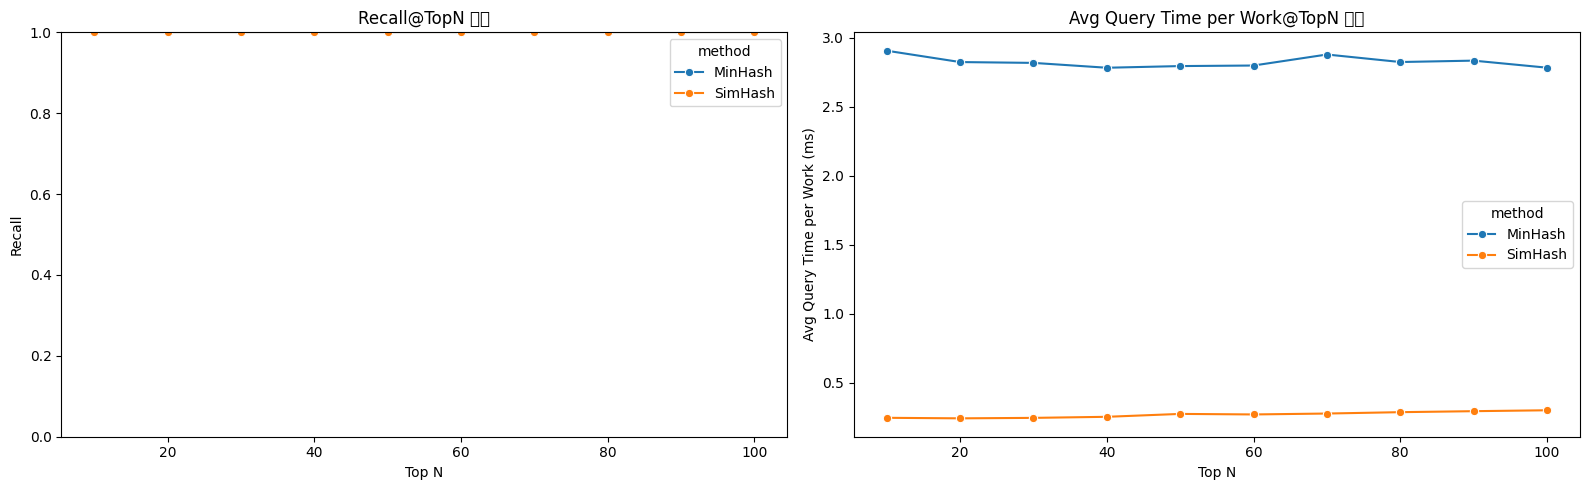

Build time 对比：


,method,build_ms,signature_doc_count,empty_shingle_doc_count
0,MinHash,3283.551167,1541,0
10,SimHash,5282.958875,1541,0


In [46]:
# cell6: 可视化 recall 与平均每 workId query time
import matplotlib.pyplot as plt
import seaborn as sns

plot_result = result_table.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=plot_result, x="top_n", y="recall", hue="method", marker="o", ax=axes[0])
axes[0].set_title("Recall@TopN 对比")
axes[0].set_xlabel("Top N")
axes[0].set_ylabel("Recall")
axes[0].set_ylim(0, 1)

sns.lineplot(data=plot_result, x="top_n", y="avg_query_ms_per_work", hue="method", marker="o", ax=axes[1])
axes[1].set_title("Avg Query Time per Work@TopN 对比")
axes[1].set_xlabel("Top N")
axes[1].set_ylabel("Avg Query Time per Work (ms)")

plt.tight_layout()
plt.show()

build_time_table = (
    result_table[["method", "build_ms", "signature_doc_count", "empty_shingle_doc_count"]]
    .drop_duplicates()
    .sort_values("method")
)
print("Build time 对比：")
display(build_time_table)


In [30]:
!pip install pandas numpy sqlalchemy pymysql jieba matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
